In [3]:
# =========================================================
# IMPORTS
# =========================================================
import os
import glob
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pdfplumber
import fitz  # PyMuPDF
import pytesseract
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
df=pd.read_csv(r'C:\Users\Rutik Bhendarkar\Chat Bot 2\Report Analysis\blood_cbc.csv')


print("Shape:", df.shape)
display(df.head())

Shape: (1281, 15)


,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


Columns: ['WBC', 'LYMp', 'NEUTp', 'LYMn', 'NEUTn', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', 'PDW', 'PCT', 'Diagnosis']

Missing values:


,missing
WBC,0
LYMp,0
NEUTp,0
LYMn,0
NEUTn,0
RBC,0
HGB,0
HCT,0
MCV,0
MCH,0



Diagnosis distribution:


,count
Diagnosis,
Healthy,336
Normocytic hypochromic anemia,279
Normocytic normochromic anemia,269
Iron deficiency anemia,189
Thrombocytopenia,73
Other microcytic anemia,59
Leukemia,47
Macrocytic anemia,18
Leukemia with thrombocytopenia,11


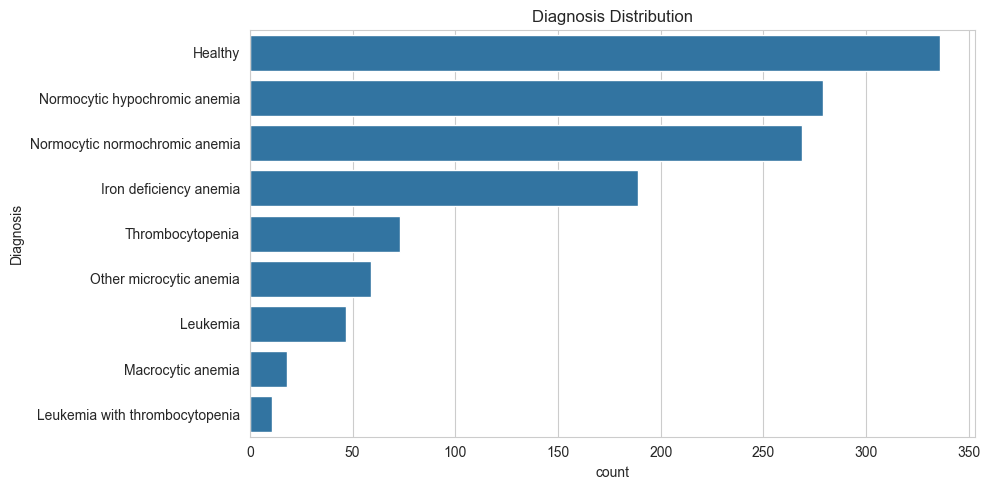

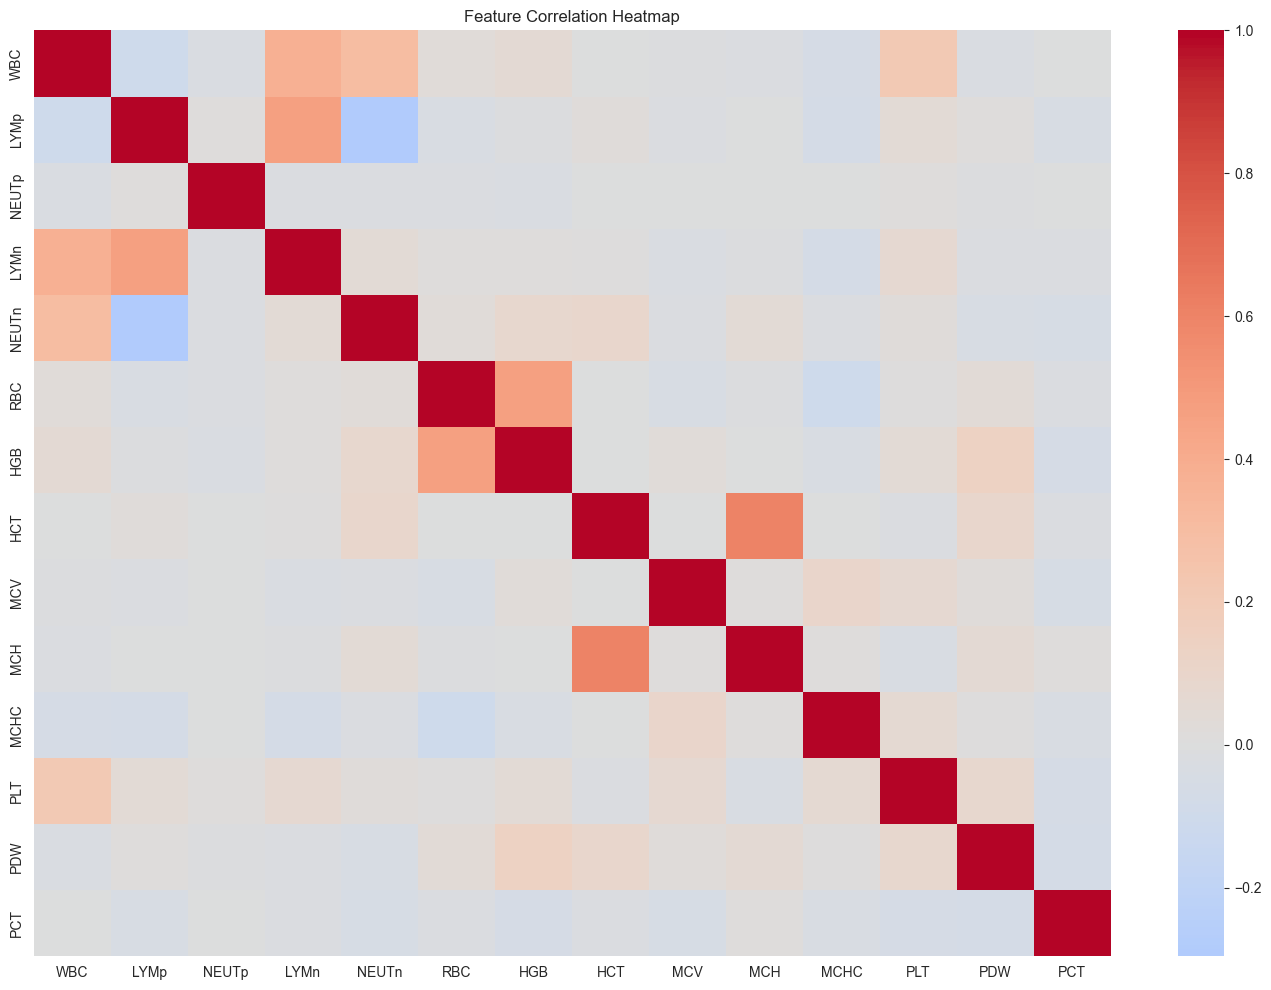

In [7]:
# =========================================================
# BASIC EDA
# =========================================================
print("Columns:", df.columns.tolist())
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))

print("\nDiagnosis distribution:")
display(df["Diagnosis"].value_counts().to_frame("count"))

plt.figure(figsize=(10, 5))
sns.countplot(y="Diagnosis", data=df, order=df["Diagnosis"].value_counts().index)
plt.title("Diagnosis Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(columns=["Diagnosis"]).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# PREPROCESSING
# =========================================================
TARGET_COL = "Diagnosis"

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = list(label_encoder.classes_)
print("Classes:", class_names)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

feature_medians = X_train.median(numeric_only=True)

X_train_filled = X_train.fillna(feature_medians)
X_test_filled = X_test.fillna(feature_medians)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

FEATURE_COLUMNS = X.columns.tolist()

print("Train shape:", X_train_filled.shape)
print("Test shape:", X_test_filled.shape)

Classes: ['Healthy', 'Iron deficiency anemia', 'Leukemia', 'Leukemia with thrombocytopenia', 'Macrocytic anemia', 'Normocytic hypochromic anemia', 'Normocytic normochromic anemia', 'Other microcytic anemia', 'Thrombocytopenia']
Train shape: (1024, 14)
Test shape: (257, 14)


In [10]:
# =========================================================
# TRAIN MODELS
# =========================================================
lr_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    class_weight="balanced_subsample"
)
rf_model.fit(X_train_filled, y_train)

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    n_estimators=120,
    learning_rate=0.08,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
xgb_model.fit(X_train_filled, y_train, sample_weight=sample_weights)

print("Models trained successfully.")

Models trained successfully.


,Model,Accuracy
1,Random Forest,0.988327
2,XGBoost,0.988327
0,Logistic Regression,0.700389



XGBoost classification report:
                                precision    recall  f1-score   support

                       Healthy       1.00      0.99      0.99        67
        Iron deficiency anemia       1.00      1.00      1.00        38
                      Leukemia       1.00      0.89      0.94         9
Leukemia with thrombocytopenia       1.00      1.00      1.00         2
             Macrocytic anemia       0.67      1.00      0.80         4
 Normocytic hypochromic anemia       0.98      1.00      0.99        56
Normocytic normochromic anemia       1.00      1.00      1.00        54
       Other microcytic anemia       1.00      0.92      0.96        12
              Thrombocytopenia       1.00      1.00      1.00        15

                      accuracy                           0.99       257
                     macro avg       0.96      0.98      0.96       257
                  weighted avg       0.99      0.99      0.99       257



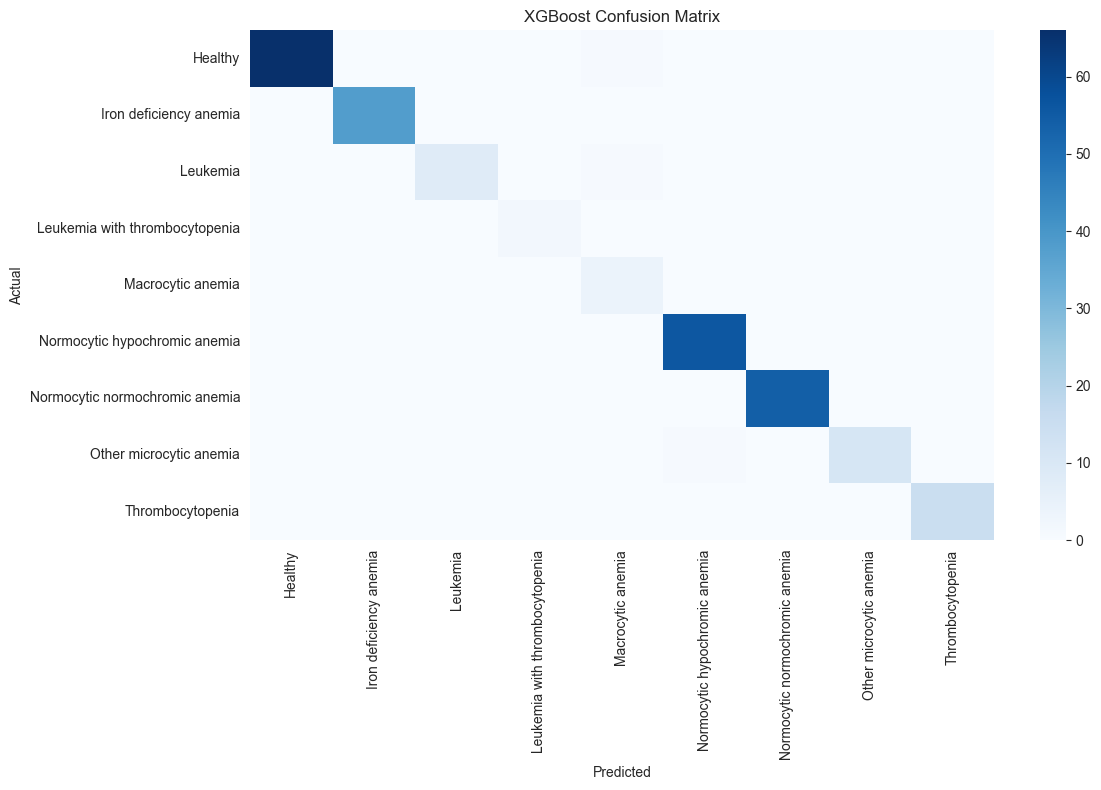

Best model: Random Forest


In [11]:
# =========================================================
# EVALUATION
# =========================================================
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_filled)
xgb_pred = xgb_model.predict(X_test_filled)

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc]
}).sort_values("Accuracy", ascending=False)

display(comparison)

print("\nXGBoost classification report:")
print(classification_report(y_test, xgb_pred, target_names=class_names))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[0]["Model"]
print("Best model:", best_model_name)

In [20]:
# =========================================================
# SAVE ARTIFACTS
# =========================================================
joblib.dump(xgb_model, "saved_models/cbc_xgb_model.pkl")
joblib.dump(scaler, "saved_models/cbc_scaler.pkl")
joblib.dump(label_encoder, "saved_models/cbc_label_encoder.pkl")
joblib.dump(feature_medians.to_dict(), "saved_models/cbc_feature_medians.pkl")
joblib.dump(FEATURE_COLUMNS, "saved_models/cbc_feature_columns.pkl")

print("Saved model artifacts successfully.")

Saved model artifacts successfully.


## Report Analyzer Layer

The next cells build the OCR + text extraction + value extraction + prediction + summary pipeline.

In [21]:
# =========================================================
# OCR + TEXT CLEANING
# =========================================================
def clean_extracted_text(text: str) -> str:
    text = re.sub(r"[\t ]+", " ", str(text))
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"[^\w\s:./%\-()]", " ", text)
    return text.strip()

def extract_text_from_image(image_path: str) -> str:
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img)
        return clean_extracted_text(text)
    except Exception as e:
        print("Image OCR error:", e)
        return ""

def extract_text_from_pdf(pdf_path: str) -> str:
    '''
    Tries direct text extraction first.
    Falls back to OCR for scanned pages.
    '''
    all_text = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages, start=1):
                page_text = page.extract_text()
                if page_text and page_text.strip():
                    all_text.append(f"--- PAGE {i} ---\n{page_text}")
                else:
                    doc = fitz.open(pdf_path)
                    page_obj = doc[i - 1]
                    pix = page_obj.get_pixmap(dpi=300)
                    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
                    ocr_text = pytesseract.image_to_string(img)
                    all_text.append(f"--- PAGE {i} (OCR) ---\n{ocr_text}")
                    doc.close()
        return clean_extracted_text("\n".join(all_text))
    except Exception as e:
        print("PDF extraction error:", e)
        return ""

In [22]:
# =========================================================
# MEDICAL VALUE EXTRACTION
# =========================================================
MEDICAL_PATTERNS = {
    "WBC": [r"\bWBC\b[:\s]*([0-9]*\.?[0-9]+)", r"white blood cells?[:\s]*([0-9]*\.?[0-9]+)"],
    "LYMp": [r"\bLYMp\b[:\s]*([0-9]*\.?[0-9]+)", r"lymphocytes?\s*%?[:\s]*([0-9]*\.?[0-9]+)"],
    "NEUTp": [r"\bNEUTp\b[:\s]*([0-9]*\.?[0-9]+)", r"neutrophils?\s*%?[:\s]*([0-9]*\.?[0-9]+)"],
    "LYMn": [r"\bLYMn\b[:\s]*([0-9]*\.?[0-9]+)"],
    "NEUTn": [r"\bNEUTn\b[:\s]*([0-9]*\.?[0-9]+)"],
    "RBC": [r"\bRBC\b[:\s]*([0-9]*\.?[0-9]+)", r"red blood cells?[:\s]*([0-9]*\.?[0-9]+)"],
    "HGB": [r"\bHGB\b[:\s]*([0-9]*\.?[0-9]+)", r"\bHb\b[:\s]*([0-9]*\.?[0-9]+)", r"hemoglobin[:\s]*([0-9]*\.?[0-9]+)"],
    "HCT": [r"\bHCT\b[:\s]*([0-9]*\.?[0-9]+)", r"hematocrit[:\s]*([0-9]*\.?[0-9]+)"],
    "MCV": [r"\bMCV\b[:\s]*([0-9]*\.?[0-9]+)"],
    "MCH": [r"\bMCH\b[:\s]*([0-9]*\.?[0-9]+)"],
    "MCHC": [r"\bMCHC\b[:\s]*([0-9]*\.?[0-9]+)"],
    "PLT": [r"\bPLT\b[:\s]*([0-9]*\.?[0-9]+)", r"platelets?[:\s]*([0-9]*\.?[0-9]+)"],
    "PDW": [r"\bPDW\b[:\s]*([0-9]*\.?[0-9]+)"],
    "PCT": [r"\bPCT\b[:\s]*([0-9]*\.?[0-9]+)"],
}

def _extract_first_match(text, patterns):
    for pattern in patterns:
        m = re.search(pattern, text, re.IGNORECASE)
        if m:
            try:
                return float(m.group(1))
            except:
                continue
    return None

def extract_medical_values(text: str) -> dict:
    text = clean_extracted_text(text)
    report = {}
    for feature, patterns in MEDICAL_PATTERNS.items():
        val = _extract_first_match(text, patterns)
        if val is not None:
            report[feature] = val
    return report

def build_model_input(report_values: dict) -> pd.DataFrame:
    row = {}
    medians = joblib.load("cbc_feature_medians.pkl") if os.path.exists("cbc_feature_medians.pkl") else feature_medians.to_dict()
    for feature in FEATURE_COLUMNS:
        row[feature] = report_values.get(feature, medians.get(feature, 0.0))
    return pd.DataFrame([row], columns=FEATURE_COLUMNS)

In [23]:
# =========================================================
# ML PREDICTION (TOP-3)
# =========================================================
def predict_top3(report_values: dict):
    input_df = build_model_input(report_values)
    probs = xgb_model.predict_proba(input_df)[0]
    top_idx = np.argsort(probs)[-3:][::-1]
    top3 = []
    for idx in top_idx:
        top3.append({
            "diagnosis": label_encoder.inverse_transform([idx])[0],
            "confidence": float(round(float(probs[idx]) * 100, 2))
        })
    return top3

def predict_best(report_values: dict):
    top3 = predict_top3(report_values)
    return top3[0] if top3 else {"diagnosis": "Unknown", "confidence": 0.0}

In [24]:
# =========================================================
# RULE-BASED MEDICAL ENGINE
# =========================================================
def blood_rule_engine(report):
    findings = []
    risk_score = 0

    def add(parameter, severity, message, points):
        nonlocal risk_score
        findings.append({
            "parameter": parameter,
            "severity": severity,
            "message": message
        })
        risk_score += points

    hgb = report.get("HGB")
    if hgb is not None:
        if hgb < 8:
            add("HGB", "CRITICAL", "Very low hemoglobin detected. Severe anemia risk.", 30)
        elif hgb < 10:
            add("HGB", "HIGH", "Low hemoglobin detected. Anemia risk present.", 20)
        elif hgb < 12:
            add("HGB", "MODERATE", "Mildly low hemoglobin detected.", 10)

    plt_count = report.get("PLT")
    if plt_count is not None:
        if plt_count < 50:
            add("PLT", "CRITICAL", "Very low platelet count. Bleeding risk may be high.", 30)
        elif plt_count < 100:
            add("PLT", "HIGH", "Low platelet count detected.", 20)
        elif plt_count < 150:
            add("PLT", "MODERATE", "Mild thrombocytopenia risk detected.", 10)

    wbc = report.get("WBC")
    if wbc is not None:
        if wbc > 20:
            add("WBC", "CRITICAL", "Extremely high WBC detected. Serious infection or hematologic risk.", 30)
        elif wbc > 11:
            add("WBC", "HIGH", "High WBC detected. Infection or inflammation risk present.", 20)
        elif wbc < 4:
            add("WBC", "MODERATE", "Low WBC detected. Immune-related risk may be present.", 10)

    rbc = report.get("RBC")
    if rbc is not None and rbc < 3.5:
        add("RBC", "HIGH", "Low RBC detected. Blood oxygen carrying capacity may be reduced.", 15)

    hct = report.get("HCT")
    if hct is not None and hct < 30:
        add("HCT", "HIGH", "Low hematocrit detected.", 15)

    mcv = report.get("MCV")
    if mcv is not None:
        if mcv < 80:
            add("MCV", "MODERATE", "Low MCV suggests microcytic red cells.", 8)
        elif mcv > 100:
            add("MCV", "MODERATE", "High MCV suggests macrocytic red cells.", 8)

    mch = report.get("MCH")
    if mch is not None and mch < 27:
        add("MCH", "MODERATE", "Low MCH suggests less hemoglobin in red cells.", 8)

    mchc = report.get("MCHC")
    if mchc is not None and mchc < 32:
        add("MCHC", "MODERATE", "Low MCHC suggests hypochromic red cells.", 8)

    pct = report.get("PCT")
    if pct is not None and pct < 0.10:
        add("PCT", "HIGH", "Very low plateletcrit detected.", 15)

    if risk_score >= 70:
        overall_risk = "CRITICAL"
    elif risk_score >= 45:
        overall_risk = "HIGH"
    elif risk_score >= 20:
        overall_risk = "MODERATE"
    else:
        overall_risk = "LOW"

    return {
        "findings": findings,
        "risk_score": risk_score,
        "overall_risk": overall_risk
    }

In [25]:
# =========================================================
# HUMAN-FRIENDLY EXPLANATION + SUMMARY
# =========================================================
DIAGNOSIS_EXPLANATIONS = {
    "Healthy": "The CBC pattern is generally within a normal range.",
    "Iron deficiency anemia": "The pattern suggests low iron-related red blood cell indices.",
    "Normocytic hypochromic anemia": "Red cells may be normal in size but contain less hemoglobin than expected.",
    "Normocytic normochromic anemia": "Red cells are close to normal size and color, but hemoglobin may still be low.",
    "Other microcytic anemia": "Red blood cells appear smaller than normal, suggesting a microcytic anemia pattern.",
    "Macrocytic anemia": "Red blood cells appear larger than normal, which may suggest macrocytic anemia.",
    "Thrombocytopenia": "Platelet count is reduced, which can increase bleeding risk.",
    "Leukemia": "The blood pattern may indicate a serious hematologic abnormality and needs medical evaluation.",
    "Leukemia with thrombocytopenia": "The pattern suggests a serious blood disorder with low platelets."
}

def generate_human_explanation(top3, rule_result):
    lines = []
    lines.append("=== AI Blood Report Explanation ===")
    if top3:
        best = top3[0]
        diagnosis = best["diagnosis"]
        confidence = best["confidence"]
        lines.append(f"Most likely diagnosis: {diagnosis}")
        lines.append(f"Model confidence: {confidence}%")
        lines.append(DIAGNOSIS_EXPLANATIONS.get(diagnosis, "The model detected a blood pattern that needs review."))
    lines.append("")
    lines.append(f"Overall Risk Level: {rule_result['overall_risk']}")
    lines.append(f"Risk Score: {rule_result['risk_score']}")
    lines.append("")
    lines.append("Abnormal Findings:")
    if rule_result["findings"]:
        for item in rule_result["findings"]:
            lines.append(f"- {item['parameter']} [{item['severity']}] → {item['message']}")
    else:
        lines.append("- No major abnormal findings detected.")
    lines.append("")
    lines.append("Simple Meaning:")
    if rule_result["overall_risk"] == "CRITICAL":
        lines.append("The report shows serious abnormalities and should be reviewed urgently.")
    elif rule_result["overall_risk"] == "HIGH":
        lines.append("The report shows important abnormal values that need medical attention.")
    elif rule_result["overall_risk"] == "MODERATE":
        lines.append("The report shows mild-to-moderate abnormalities and should be monitored.")
    else:
        lines.append("The report does not show a major abnormal pattern right now.")
    return "\n".join(lines)

def generate_final_summary(top3, rule_result):
    lines = []
    lines.append("=========== CBC REPORT SUMMARY ===========")
    lines.append("")
    if top3:
        lines.append("AI Prediction:")
        for item in top3:
            lines.append(f"- {item['diagnosis']} ({item['confidence']}%)")
        lines.append("")
    lines.append(f"Overall Health Risk Level: {rule_result['overall_risk']}")
    lines.append(f"Risk Score: {rule_result['risk_score']}")
    lines.append("")
    lines.append("Medical Findings:")
    if rule_result["findings"]:
        for item in rule_result["findings"]:
            lines.append(f"- {item['parameter']} [{item['severity']}] → {item['message']}")
    else:
        lines.append("- No major abnormal findings detected.")
    lines.append("")
    lines.append("Next Step:")
    if rule_result["overall_risk"] == "CRITICAL":
        lines.append("- Seek medical consultation urgently.")
    elif rule_result["overall_risk"] == "HIGH":
        lines.append("- Discuss the report with a doctor soon.")
    elif rule_result["overall_risk"] == "MODERATE":
        lines.append("- Monitor the report and consider follow-up testing.")
    else:
        lines.append("- Maintain routine health monitoring.")
    lines.append("")
    lines.append("This AI summary is supportive and educational only, not a replacement for a clinician.")
    return "\n".join(lines)

In [26]:
# =========================================================
# COMPLETE REPORT ANALYSIS PIPELINE
# =========================================================
def analyze_report_text(report_text: str):
    values = extract_medical_values(report_text)
    top3 = predict_top3(values)
    rule_result = blood_rule_engine(values)
    explanation = generate_human_explanation(top3, rule_result)
    summary = generate_final_summary(top3, rule_result)
    return {
        "values": values,
        "top3": top3,
        "rule_result": rule_result,
        "explanation": explanation,
        "summary": summary
    }

def analyze_report_file(file_path: str):
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".pdf":
        text = extract_text_from_pdf(file_path)
    else:
        text = extract_text_from_image(file_path)
    return analyze_report_text(text)

In [27]:
# =========================================================
# END-TO-END TEST
# =========================================================
sample_report_text = '''
WBC: 10.0
LYMp: 43.2
NEUTp: 50.1
LYMn: 4.3
NEUTn: 5.0
RBC: 2.77
HGB: 7.3
HCT: 24.2
MCV: 87.7
MCH: 26.3
MCHC: 30.1
PLT: 189
PDW: 12.5
PCT: 0.17
'''

result = analyze_report_text(sample_report_text)
print("Extracted Values:")
display(pd.DataFrame([result["values"]]))

print("\nTop-3 Predictions:")
for item in result["top3"]:
    print(item)

print("\nRule Engine Result:")
print(result["rule_result"])

print("\nHuman Explanation:")
print(result["explanation"])

print("\nFinal Summary:")
print(result["summary"])

Extracted Values:


,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17



Top-3 Predictions:
{'diagnosis': 'Normocytic hypochromic anemia', 'confidence': 99.82}
{'diagnosis': 'Macrocytic anemia', 'confidence': 0.04}
{'diagnosis': 'Normocytic normochromic anemia', 'confidence': 0.03}

Rule Engine Result:
{'findings': [{'parameter': 'HGB', 'severity': 'CRITICAL', 'message': 'Very low hemoglobin detected. Severe anemia risk.'}, {'parameter': 'RBC', 'severity': 'HIGH', 'message': 'Low RBC detected. Blood oxygen carrying capacity may be reduced.'}, {'parameter': 'HCT', 'severity': 'HIGH', 'message': 'Low hematocrit detected.'}, {'parameter': 'MCH', 'severity': 'MODERATE', 'message': 'Low MCH suggests less hemoglobin in red cells.'}, {'parameter': 'MCHC', 'severity': 'MODERATE', 'message': 'Low MCHC suggests hypochromic red cells.'}], 'risk_score': 76, 'overall_risk': 'CRITICAL'}

Human Explanation:
=== AI Blood Report Explanation ===
Most likely diagnosis: Normocytic hypochromic anemia
Model confidence: 99.82%
Red cells may be normal in size but contain less hem

## Ready-to-use functions

- `extract_text_from_pdf(pdf_path)`
- `extract_text_from_image(image_path)`
- `extract_medical_values(text)`
- `predict_top3(report_values)`
- `blood_rule_engine(report)`
- `analyze_report_text(report_text)`
- `analyze_report_file(file_path)`

Save the notebook after your final run if you want to keep trained artifacts and outputs.